<a href="https://colab.research.google.com/github/anshupandey/B7_GAAP_GCP/blob/main/code14_GraphRAG_with_LangGraph_llamaindex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GraphRAG Implementation

#### Objectives

1. explain why GraphRAG is useful after standard RAG
2. reuse the same PDF corpus from the earlier notebook
3. build a property graph index from those PDFs
4. compare vector retrieval with graph-aware retrieval
5. use LangGraph to orchestrate a GraphRAG answer flow
6. understand where LangGraph fits and where it does not



**Standard RAG**

The model answers from the most similar chunks.

**GraphRAG**

The model answers from the most relevant chunks **plus** the entity and relationship structure extracted from the corpus.

So the jump from RAG to GraphRAG is not "replace retrieval with a graph database".

It is better described as:

- keep document retrieval
- add graph structure
- use the graph structure to improve retrieval and reasoning


## Popular Package Choices for GraphRAG

There is not just one GraphRAG package in practice. The most commonly discussed options today are:

1. **Microsoft GraphRAG**
   Good when you want the official research-oriented GraphRAG pipeline with indexing, community reports, local search, and global search.

2. **Neo4j GraphRAG (`neo4j-graphrag`)**
   Good when you want a production-style graph database workflow and a first-party Neo4j package.

3. **LlamaIndex `PropertyGraphIndex`**
   Good for notebook teaching because it is relatively compact, graph-native, and easy to show step by step.

4. **LangGraph**
   Important point: LangGraph is an orchestration framework. It helps us structure the workflow, but it does **not** by itself build the graph index.

### Why this notebook chooses LlamaIndex + LangGraph

For an example session, this combination is practical:

- `LangChain` style PDF ingestion stays familiar
- `LlamaIndex` gives us a real graph index from unstructured text
- `LangGraph` lets us preserve the same "workflow graph" teaching style from your current notebook


## Session Design Choice

Since your participants have already seen standard RAG, this notebook is organized as:

1. Reuse the same PDFs and preprocessing logic
2. Briefly recreate the standard vector index for comparison
3. Build a property graph index from the same chunks
4. Run graph retrieval
5. Wrap the answer flow in LangGraph



In [1]:
# Install the core packages for this notebook.

!python -m pip install -U \
    langchain-community langchain-google-genai langchain-chroma langchain-text-splitters \
    langgraph pypdf faiss-cpu chromadb \
    llama-index llama-index-core \
    llama-index-llms-google-genai llama-index-embeddings-google-genai \
    llama-index-vector-stores-chroma \
    networkx matplotlib --quiet


## Imports and Model Setup

We will keep the model setup close to the earlier notebook so the class sees continuity.

- Gemini chat model for answer generation
- Google embeddings for vector search
- LlamaIndex Google GenAI wrappers for the property graph index


In [1]:
import os
embedding_model_name = "models/gemini-embedding-001"
model_name = "gemini-2.5-flash"

## Step 1: Reuse the Same PDF Corpus

We will use the same PDF sources from the earlier RAG notebook.


In [2]:
doc_paths = [
    "https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf",
    "https://s21.q4cdn.com/198919461/files/doc_downloads/press_kits/2016/Morningstar-Sustainable-Investing-Handbook.pdf",
]
doc_paths


['https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf',
 'https://s21.q4cdn.com/198919461/files/doc_downloads/press_kits/2016/Morningstar-Sustainable-Investing-Handbook.pdf']

## Step 2: Load the PDFs

We keep the same loader approach as the original notebook so learners see that the corpus preparation stage has not fundamentally changed.


In [3]:
from langchain_community.document_loaders import PyPDFLoader

loaders = [PyPDFLoader(pdf, extract_images=False) for pdf in doc_paths]
docs = []

for loader in loaders:
    loaded_docs = loader.load()
    docs.extend(loaded_docs)

print("Total loaded pages:", len(docs))


Total loaded pages: 25


In [4]:
docs[0]


Document(metadata={'producer': 'GPL Ghostscript 9.06', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2021-02-26T12:11:18+05:30', 'moddate': '2021-02-26T12:11:18+05:30', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'author': 'KBelapu', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'total_pages': 12, 'page': 0, 'page_label': '1'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total assets in large-cap stocks. \nMorningstar Category Index: S&P BSE 100 TR \n \nMid-Cap \nMid-Cap funds primar

## Step 3: Light Cleanup

We will keep the same cleanup idea from the original notebook:

- drop nearly empty pages
- keep only pages with meaningful text


In [5]:
docs = [doc for doc in docs if len(doc.page_content.strip()) > 100]
print("Pages after cleanup:", len(docs))


Pages after cleanup: 24


In [6]:
avg_chars = sum(len(doc.page_content) for doc in docs) / len(docs)
print("Average characters per remaining page:", round(avg_chars, 2))


Average characters per remaining page: 1988.08


## Step 4: Split into Chunks

This is still useful in GraphRAG.

Even though we are building a graph, the graph is still extracted from text units or chunks. So chunking remains part of the pipeline.


In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=3000,
    chunk_overlap=500
)
splits = text_splitter.split_documents(docs)

print("Number of chunks:", len(splits))


Number of chunks: 27


In [8]:
print(splits[1].page_content[:2500])


©2019 Morningstar, Inc. All rights reserved. The information in this document is the property of Morningstar, Inc. Reproduction or transcription by any means, in whole or part, without  
the prior written consent of Morningstar, Inc., is prohibited. 
Category Definitions , India  | 26 February 2021  Page 2 of 12  
Multi- Cap 
Multi-Cap funds invest at least 75% of their total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. These funds 
will invest a minimum of 25% each in Large Cap, Mid Cap and Small Cap stocks. 
Morningstar Category Index: S&P BSE 500 TR 
 
 
Large & Mid- Cap 
Large & Mid-Cap funds primarily consist of stocks which are the Top 250 stocks by full market 
capitalization of the equity market. These funds invest at least 70% of total assets in Indian equities and 
the balance can be invested in other asset classes such as fixed income and overseas equities, among 
others. Funds in

## Step 5: Build a Standard Vector Store First

We will do this briefly for one reason:

it gives us a baseline to compare against GraphRAG.

This also keeps the notebook aligned with the earlier tutorial.


In [9]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain.chat_models import init_chat_model

embeddings = GoogleGenerativeAIEmbeddings(model=embedding_model_name)
llm = init_chat_model("google_genai:gemini-2.5-flash")

In [10]:


vector_db_path = "VectorDB_Chroma"
os.makedirs(vector_db_path, exist_ok=True)

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory=vector_db_path,
    collection_name="morningstar_graphrag_demo200",
    collection_metadata={"use_case": "training_demo"}
)

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

print("Vector store ready.")


Vector store ready.


In [11]:
baseline_docs = retriever.invoke("What is a large cap equity fund?")
len(baseline_docs)


3

In [12]:
print(baseline_docs[0].page_content[:2000])


? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. Funds in this 
category would invest at least 65% of their total assets in mid-cap stocks. 
Morningstar Category Index: S&P BSE Mid Cap TR 
 
Small-Cap 
Small-Cap fun

## What Changes Now for GraphRAG?

Up to this point, the notebook looks familiar.

Now we add the graph layer.

The property graph index will try to extract:

- entities
- relationship paths
- graph connections between concepts

from the same document chunks.


## Step 6: Convert the Chunks into LlamaIndex Documents

We are keeping the data source and chunking approach from LangChain, but for the graph index we will hand the chunks to LlamaIndex.


In [13]:
from llama_index.core import Document as LlamaDocument

llama_docs = []
for i, doc in enumerate(splits):
    llama_docs.append(
        LlamaDocument(
            text=doc.page_content,
            metadata={
                "source": doc.metadata.get("source", ""),
                "page": doc.metadata.get("page", ""),
                "chunk_id": i,
            },
        )
    )

print("Converted chunks for LlamaIndex:", len(llama_docs))

Converted chunks for LlamaIndex: 27


## Step 7: Create the Property Graph Index

This is the GraphRAG step.

Behind the scenes, the property graph index will:

- parse the documents into nodes
- extract graph paths from text using the LLM
- create embeddings for graph nodes and text nodes

In a live session, it is worth pausing here and reminding participants:

**GraphRAG still uses language models during indexing.**


In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
!pip install llama-index-llms-langchain --quiet

In [23]:
!pip install llama-index-embeddings-langchain --quiet

In [15]:
from llama_index.llms.langchain import LangChainLLM
from llama_index.embeddings.langchain import LangchainEmbedding
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding
llama_llm = LangChainLLM(llm=llm)
llama_embed_model = LangchainEmbedding(langchain_embeddings=embeddings)

In [16]:
from llama_index.core import PropertyGraphIndex
from llama_index.llms.google_genai import GoogleGenAI
import nest_asyncio

nest_asyncio.apply()

#llama_llm = GoogleGenAI(model=f"models/{model_name}",api_key=os.getenv('GOOGLE_API_KEY'),vertexai_configuratio)
#llama_embed_model = GoogleGenAIEmbedding(model_name=embedding_model_name,api_key=os.getenv('GOOGLE_API_KEY'))

graph_index = PropertyGraphIndex.from_documents(
    llama_docs,
    llm=llama_llm,
    embed_model=llama_embed_model,
    show_progress=True,
)

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Applying transformations:   0%|          | 0/2 [00:00<?, ?it/s]

Generating embeddings: 100%|██████████| 52/52 [00:03<00:00, 16.79it/s]


## Step 8: Inspect What Was Built

This is one of the best tutorial moments in GraphRAG.

Instead of treating retrieval as a hidden step, we can inspect graph-driven outputs.


In [17]:
graph_retriever = graph_index.as_retriever(include_text=True)

In [19]:
#from llama_index.core.indices.property_graph.retriever import PropertyGraphRetriever

#graph_retriever = PropertyGraphRetriever(
 #   index=graph_index,
 #   include_text=True,
 #   similarity_top_k=4,
 #   use_async=False # Explicitly ensure this is False
#)

import asyncio

async def get_graph_nodes():
    return await graph_retriever.aretrieve("What is a large cap equity fund?")

graph_nodes = asyncio.run(get_graph_nodes())
len(graph_nodes)

2

In [20]:
for i, node in enumerate(graph_nodes[:3], start=1):
    print(f"--- Result {i} ---")
    print(node.text[:2000])
    print()


--- Result 1 ---
Here are some facts extracted from the provided text:

Large-cap funds -> Invest 80% assets -> Indian equities
Large-cap funds -> Comprise -> Top 100 stocks
Large-cap -> Morningstar category index -> S&p bse 100 tr

? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset

## What the Graph Retriever is Actually Doing

A useful explanation for participants is:

1. find graph nodes related to the query
2. walk outward to related nodes and paths
3. optionally bring back supporting source text
4. pass a richer context to the answering model

That is the key behavior difference from plain top-k chunk retrieval.


## Step 9: A Quick Comparison Between Standard Retrieval and Graph Retrieval

We will compare the kinds of evidence returned by:

- vector retrieval
- graph retrieval


In [21]:
question = "How does Morningstar define a large cap equity fund in India?"

print("VECTOR RETRIEVAL")
print("=" * 80)
for i, doc in enumerate(retriever.invoke(question), start=1):
    print(f"Vector chunk {i}")
    print(doc.page_content[:1200])
    print("\n")

print("\nGRAPH RETRIEVAL")
print("=" * 80)

import asyncio

async def get_graph_retrieval_results():
    return await graph_retriever.aretrieve(question)

graph_retrieval_results = asyncio.run(get_graph_retrieval_results())

for i, node in enumerate(graph_retrieval_results, start=1):
    print(f"Graph result {i}")
    print(node.text[:1200])
    print("\n")

VECTOR RETRIEVAL
Vector chunk 1
? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. Funds in this 
category would invest at least 65% of their total assets in mid-cap stocks. 
Morningstar Category Index: S&P BSE Mid Ca

## Step 10: Build the Final Answer Prompt

We will keep the answer generation style close to the earlier notebook:

- answer only from retrieved context
- do not invent information
- stay grounded in the retrieved evidence


In [22]:
from langchain_core.prompts import PromptTemplate

graph_message = '''
Answer the question using only the context below.
The context may contain graph-derived relationship statements and source text.
If the context is insufficient, say that the retrieved context is not sufficient.

Question:
{question}

Context:
{context}
'''

graph_prompt = PromptTemplate.from_template(graph_message)
graph_prompt


PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer the question using only the context below.\nThe context may contain graph-derived relationship statements and source text.\nIf the context is insufficient, say that the retrieved context is not sufficient.\n\nQuestion:\n{question}\n\nContext:\n{context}\n')

In [23]:
from langchain.chat_models import init_chat_model

answer_llm = init_chat_model(model_name, model_provider="google_genai")


## Step 11: Where LangGraph Fits

Yes, we **can** do this with LangGraph.

But the right way to explain it is:

- LlamaIndex builds and queries the graph index
- LangGraph orchestrates the workflow around retrieval and generation

So LangGraph is the workflow engine, not the graph construction engine.


## Step 12: GraphRAG Chain with LangGraph

This mirrors the spirit of your existing LangGraph RAG notebook, but now the retrieval node uses a graph-aware retriever.


In [24]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END


class GraphRAGState(TypedDict, total=False):
    user_query: str
    graph_context: List[str]
    final_context: str
    response: str


In [25]:
import asyncio

async def graph_retrieval_node(state: GraphRAGState) -> GraphRAGState:
    query = state["user_query"]

    # This can now directly await the async retriever
    results = await graph_retriever.aretrieve(query)

    graph_context = [node.text for node in results]
    final_context = "\n\n".join(graph_context)

    return {
        "graph_context": graph_context,
        "final_context": final_context,
    }


def answer_generation_node(state: GraphRAGState) -> GraphRAGState:
    prompt_value = graph_prompt.invoke(
        {
            "question": state["user_query"],
            "context": state["final_context"],
        }
    )
    response = answer_llm.invoke(prompt_value)
    return {"response": response}

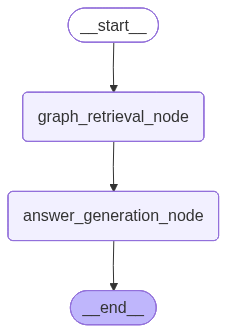

In [26]:
builder = StateGraph(GraphRAGState)
builder.add_node("graph_retrieval_node", graph_retrieval_node)
builder.add_node("answer_generation_node", answer_generation_node)

builder.add_edge(START, "graph_retrieval_node")
builder.add_edge("graph_retrieval_node", "answer_generation_node")
builder.add_edge("answer_generation_node", END)

graph_rag_app = builder.compile()
graph_rag_app


In [27]:
# import asyncio # Not needed if running directly at top level

# async def run_graph_rag_app(user_query: str): # Not needed
#     return await graph_rag_app.ainvoke(
#         {"user_query": user_query}
#     )

result = await graph_rag_app.ainvoke(
    {"user_query": "What is a large cap equity fund and how is it categorized?"}
)

print(result["response"])

content='A large cap equity fund primarily consists of the Top 100 stocks by full market capitalization of the equity market. These funds invest at least 80% of their total assets in Indian equities, with the balance potentially invested in other asset classes like fixed income and overseas equities. Funds in this category specifically invest at least 80% of their total assets in large-cap stocks.\n\nIt is categorized by the Morningstar Category Index: S&P BSE 100 TR.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019df65f-1a00-72a1-b469-27216fd36eec-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1353, 'output_tokens': 528, 'total_tokens': 1881, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 428}}


## Step 13: Ask Better GraphRAG Questions

GraphRAG is usually most valuable when the question needs relationships or synthesis.

Good examples:

- How are sustainable investing ideas connected across both PDFs?
- Which categories, definitions, and investment ideas are related to each other?
- What concepts appear repeatedly across the corpus, and how do they connect?
- How do the two documents differ in the way they describe classification and investing themes?


In [28]:
test_questions = [
    "What is a large cap equity fund?",
    "How do the documents describe sustainable investing?",
    "What are the main fund classification ideas discussed across the corpus?",
]

for q in test_questions:
    print("=" * 100)
    print("QUESTION:", q)
    out = await graph_rag_app.ainvoke({"user_query": q})
    print(out["response"])
    print()


QUESTION: What is a large cap equity fund?
content='Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization of the equity market. These funds invest at least 80% of total assets in Indian equities and at least 80% of their total assets in large-cap stocks. The balance can be invested in other asset classes such as fixed income and overseas equities.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019df65f-ad9c-7671-94f4-42fef05ecacd-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1348, 'output_tokens': 431, 'total_tokens': 1779, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 356}}

QUESTION: How do the documents describe sustainable investing?
content='The documents describe sustainable investing as:\n\n*   A **long-term approach** to investing that **incorporates en